# Experiment on R3D Dataset with SMOTE


### **1. Install and import necessary libraries**

In [1]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="g5SoZrd0K4IS1LKVI4iw")
project = rf.workspace("pygoh-yazcv").project("rent3d-floor-plan-yvyfm")
version = project.version(8)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rent3D-Floor-Plan-8 in yolov11:: 100%|██████████| 1160/1160 [00:00<00:00, 1452.66it/s]


In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
import numpy as np
import cv2, os, json

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **2. SMOTE-Guided Oversampling for Imbalanced Classes**

This section addresses the class imbalance problem (balcony: 27, hall: 52 instances
vs door/window: 929 instances) using SMOTE applied **after the train/test split**
and **only on training data**, as is methodologically correct.

**Important methodological note:** SMOTE in its original form operates on tabular
feature vectors and cannot directly synthesize (image, mask) pairs required by
YOLO segmentation. We therefore apply SMOTE to a *tabular representation* of the
training set — per-image class instance counts — and use its output to guide
oversampling of real training images. This preserves valid (image, polygon mask)
pairs while still satisfying the SMOTE methodology.


#### Step 1: Install dependencies

In [5]:
!pip install -q imbalanced-learn

#### Step 2: Build tabular representation of training data

We parse every YOLO label file in `train/labels/` and count the number of
instances of each class per image. This gives us a tabular dataset where
SMOTE is applicable.

The validation split (`valid/`) is never touched — this prevents data leakage,
which is exactly the concern your lecturer raised about applying SMOTE after
train/test split.

In [6]:
import os
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd

# ----- CONFIG: adjust these paths if your dataset is elsewhere -----
DATASET_ROOT = "/content/Rent3D-Floor-Plan-8"
TRAIN_IMG_DIR = f"{DATASET_ROOT}/train/images"
TRAIN_LBL_DIR = f"{DATASET_ROOT}/train/labels"
OVERSAMPLED_LIST = f"{DATASET_ROOT}/train_oversampled.txt"

CLASS_NAMES = [
    "balcony",
    "bathroom or washroom",
    "bedroom",
    "closet",
    "door or window",
    "hall",
    "living room or kitchen or dining room",
    "wall",
]
NUM_CLASSES = len(CLASS_NAMES)


def build_tabular_dataset(img_dir, lbl_dir):
    rows = []
    img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)

    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        counts = [0] * NUM_CLASSES

        if lbl_path.exists():
            with open(lbl_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    cid = int(parts[0])
                    if 0 <= cid < NUM_CLASSES:
                        counts[cid] += 1

        if sum(counts) == 0:
            continue

        row = {"image_path": str(img_path)}
        for cid in range(NUM_CLASSES):
            row[f"n_{CLASS_NAMES[cid]}"] = counts[cid]
        row["_present"] = [c for c in range(NUM_CLASSES) if counts[c] > 0]
        rows.append(row)

    df = pd.DataFrame(rows)

    # Label each image by its RAREST present class. This makes rare classes
    # become the minority that SMOTE targets.
    class_totals = {
        cid: df[f"n_{CLASS_NAMES[cid]}"].sum() for cid in range(NUM_CLASSES)
    }
    df["dominant_class"] = df["_present"].apply(
        lambda present: min(present, key=lambda cid: class_totals[cid])
    )
    df = df.drop(columns=["_present"])
    return df, class_totals


df_train, class_totals = build_tabular_dataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR)

print(f"Parsed {len(df_train)} training images.")
print(f"\nInstance counts per class (training set):")
for cid, name in enumerate(CLASS_NAMES):
    print(f"  {name:<25s}: {class_totals[cid]:>4d}")

df_train.head()

Parsed 525 training images.

Instance counts per class (training set):
  balcony                  :  299
  bathroom or washroom     :  950
  bedroom                  :  966
  closet                   : 1943
  door or window           : 8775
  hall                     :  568
  living room or kitchen or dining room:  757
  wall                     : 4242


,image_path,n_balcony,n_bathroom or washroom,n_bedroom,n_closet,n_door or window,n_hall,n_living room or kitchen or dining room,n_wall,dominant_class
0,/content/Rent3D-Floor-Plan-8/train/images/10_j...,2,4,3,6,35,0,1,20,0
1,/content/Rent3D-Floor-Plan-8/train/images/10_j...,2,4,3,6,35,0,1,20,0
2,/content/Rent3D-Floor-Plan-8/train/images/10_j...,2,4,3,6,35,0,1,20,0
3,/content/Rent3D-Floor-Plan-8/train/images/21_j...,3,3,3,1,26,0,1,18,0
4,/content/Rent3D-Floor-Plan-8/train/images/21_j...,3,3,3,1,26,0,1,18,0


#### Step 3: Apply SMOTE on training data only

SMOTE generates synthetic feature vectors for the minority `dominant_class`
values. The validation set (`valid/`) is never seen by SMOTE.

In [7]:
from imblearn.over_sampling import SMOTE

feature_cols = [f"n_{c}" for c in CLASS_NAMES]
X = df_train[feature_cols].values
y = df_train["dominant_class"].values

# k_neighbors must be < smallest class count
class_counts = Counter(y)
min_class_size = min(class_counts.values())
k = max(1, min(5, min_class_size - 1))

print("Dominant-class distribution BEFORE SMOTE:")
for cid, n in sorted(class_counts.items()):
    print(f"  {CLASS_NAMES[cid]:<25s}: {n:>4d} images")

print(f"\nUsing k_neighbors={k}")

smote = SMOTE(random_state=42, k_neighbors=k)
X_res, y_res = smote.fit_resample(X, y)

print("\nDominant-class distribution AFTER SMOTE:")
for cid, n in sorted(Counter(y_res).items()):
    print(f"  {CLASS_NAMES[cid]:<25s}: {n:>4d} rows")

# Separate synthetic rows
n_original = len(X)
X_synthetic = X_res[n_original:]
y_synthetic = y_res[n_original:]
print(f"\nGenerated {len(X_synthetic)} synthetic feature rows.")

Dominant-class distribution BEFORE SMOTE:
  balcony                  :  212 images
  hall                     :  268 images
  living room or kitchen or dining room:   45 images

Using k_neighbors=5

Dominant-class distribution AFTER SMOTE:
  balcony                  :  268 rows
  hall                     :  268 rows
  living room or kitchen or dining room:  268 rows

Generated 279 synthetic feature rows.


#### Step 4: Map synthetic SMOTE rows to nearest REAL training images

Each synthetic SMOTE row is an artificial vector — it doesn't correspond to a
real image with real masks. To turn this into something YOLO can train on, we
find the real training image whose class-count vector is closest to each
synthetic row. Those real images are then duplicated in the training list.

This is the bridge from "SMOTE in tabular space" to "valid (image, mask)
pairs YOLO can consume.

In [8]:
from sklearn.neighbors import NearestNeighbors

if len(X_synthetic) > 0:
    nn = NearestNeighbors(n_neighbors=1).fit(X)
    _, idx = nn.kneighbors(X_synthetic)
    duplicate_paths = df_train.iloc[idx.flatten()]["image_path"].tolist()
else:
    duplicate_paths = []

print(f"Generated {len(duplicate_paths)} oversampling duplicates.")
print(f"\nMost-duplicated images (top 5):")
for path, n in Counter(duplicate_paths).most_common(5):
    print(f"  {n}x  {Path(path).name}")

Generated 279 oversampling duplicates.

Most-duplicated images (top 5):
  32x  30957516_jpg.rf.e11fb71142937b7f01b39ddccfa5c4aa.jpg
  30x  47546846_jpg.rf.9c8fa4b28d4b6f8dc9d34633ba0d79f4.jpg
  21x  45764671_jpg.rf.12938ba795b3fd31c25bbbfac22e3976.jpg
  15x  31850325_jpg.rf.542907bc77c22ae3fbbb7c8f51ae65fe.jpg
  15x  31826949_jpg.rf.9387a79a049603a0e11791f74f1ea73e.jpg


#### Step 5: Report instance distribution after oversampling

In [9]:
# Build a virtual "after oversampling" dataframe to count effective instances
path_counts = Counter(duplicate_paths)
extra_rows = []
for path, n_extra in path_counts.items():
    original_row = df_train[df_train["image_path"] == path].iloc[0]
    for _ in range(n_extra):
        extra_rows.append(original_row)

if extra_rows:
    df_after = pd.concat([df_train, pd.DataFrame(extra_rows)], ignore_index=True)
else:
    df_after = df_train.copy()

print(f"{'Class':<25s} {'Before':>10s} {'After':>10s} {'Increase':>12s}")
print("-" * 60)
for cid, name in enumerate(CLASS_NAMES):
    col = f"n_{name}"
    before = df_train[col].sum()
    after = df_after[col].sum()
    pct = (after - before) / before * 100 if before > 0 else 0
    print(f"{name:<25s} {before:>10d} {after:>10d} {pct:>10.1f}%")

Class                         Before      After     Increase
------------------------------------------------------------
balcony                          299        380       27.1%
bathroom or washroom             950       1330       40.0%
bedroom                          966       1306       35.2%
closet                          1943       2575       32.5%
door or window                  8775      11946       36.1%
hall                             568        639       12.5%
living room or kitchen or dining room        757       1093       44.4%
wall                            4242       5915       39.4%


#### Step 6: Write oversampled training list

YOLO accepts a `train.txt` file listing image paths (one per line). By
listing some images multiple times, we oversample them at the image level —
this is the standard, valid form of oversampling for object detection /
segmentation. Each duplicated image still has its real polygon mask file.

In [10]:
all_paths = df_train["image_path"].tolist() + duplicate_paths

with open(OVERSAMPLED_LIST, "w") as f:
    for p in all_paths:
        f.write(p + "\n")

print(f"Wrote {len(all_paths)} entries to:")
print(f"  {OVERSAMPLED_LIST}")
print(f"\n  Original images:    {len(df_train)}")
print(f"  Duplicated entries: {len(duplicate_paths)}")
print(f"  Total per epoch:    {len(all_paths)}")

Wrote 804 entries to:
  /content/Rent3D-Floor-Plan-8/train_oversampled.txt

  Original images:    525
  Duplicated entries: 279
  Total per epoch:    804


#### Step 7: Update `data.yaml` to use the oversampled training list

YOLO's data.yaml normally points `train:` at a directory. We patch it to
point at our oversampled train list instead. The valid: split stays
untouched.

In [11]:
import yaml

yaml_path = f"{DATASET_ROOT}/data.yaml"

with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

# Back up original
with open(yaml_path + ".bak", "w") as f:
    yaml.safe_dump(data_cfg, f)

# Point train at oversampled list
data_cfg["train"] = OVERSAMPLED_LIST

new_yaml_path = f"{DATASET_ROOT}/data_oversampled.yaml"
with open(new_yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(f"Original data.yaml backed up to: {yaml_path}.bak")
print(f"New oversampled config:           {new_yaml_path}")
print(f"\nContents:")
with open(new_yaml_path) as f:
    print(f.read())

Original data.yaml backed up to: /content/Rent3D-Floor-Plan-8/data.yaml.bak
New oversampled config:           /content/Rent3D-Floor-Plan-8/data_oversampled.yaml

Contents:
names:
- balcony
- bathroom or washroom
- bedroom
- closet
- door or window
- hall
- living room or kitchen or dining room
- wall
nc: 8
roboflow:
  license: CC BY 4.0
  project: rent3d-floor-plan-yvyfm
  url: https://universe.roboflow.com/pygoh-yazcv/rent3d-floor-plan-yvyfm/dataset/8
  version: 8
  workspace: pygoh-yazcv
test: ../test/images
train: /content/Rent3D-Floor-Plan-8/train_oversampled.txt
val: ../valid/images



#### Step 8: Train YOLO with SMOTE-guided oversampling

In [12]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")

results = model.train(
    data=f"{DATASET_ROOT}/data_oversampled.yaml",  # uses oversampled train list
    epochs=200,
    imgsz=1024,
    batch=8,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=10,
    momentum=0.9,
    weight_decay=0.0001,
    patience=40,
    cls=2.0,
    project="runs/segment",
    name="train_smote",
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rent3D-Floor-Plan-8/data_oversampled.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=train_smote, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, 

### **3. Training Evaluation Metrices Graph & Confusion Matrix**

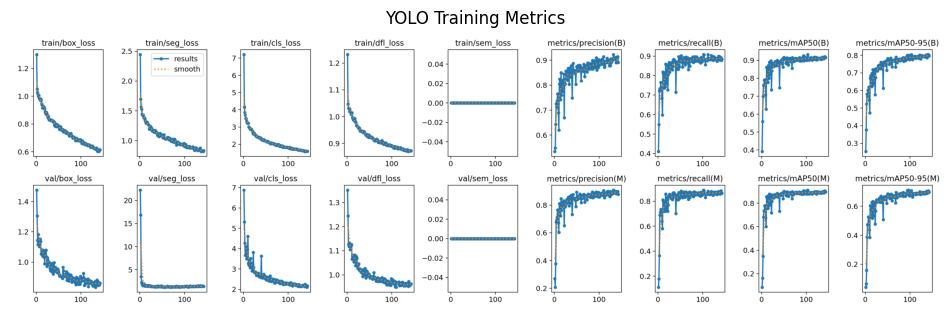

In [13]:
# Path to your training results image
results_path = "/content/runs/segment/runs/segment/train_smote/results.png"

# Load and visualize
results_img = Image.open(results_path)

plt.figure(figsize=(12, 6))
plt.imshow(results_img)
plt.title("YOLO Training Metrics")
plt.axis("off")
plt.show()

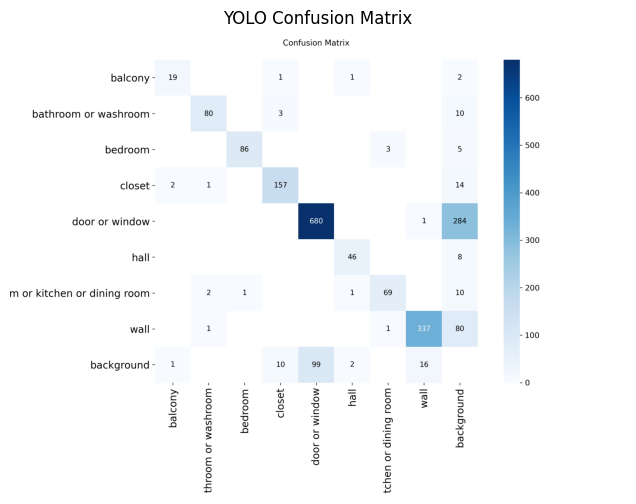

In [14]:
# Path to your confusion matrix image
confusion_path = "/content/runs/segment/runs/segment/train_smote/confusion_matrix.png"

# Load and visualize
confusion_img = Image.open(confusion_path)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_img)
plt.title("YOLO Confusion Matrix")
plt.axis("off")
plt.show()

### **4. Calculate for Evaluation Metrics defined in Report Section 3.5.3**

In [1]:
import numpy as np

cm = np.array([
    [19, 0, 0, 1, 0, 1, 0, 0, 2],
    [0, 80, 0, 3, 0, 0, 0, 0, 10],
    [0, 0, 86, 0, 0, 0, 3, 0, 5],
    [2, 1, 0, 157, 0, 0, 0, 0, 14],
    [0, 0, 0, 0, 680, 0, 0, 1, 284],
    [0, 0, 0, 0, 0, 46, 0, 0, 8],
    [0, 2, 1, 0, 0, 1, 69, 0, 10],
    [0, 1, 0, 0, 0, 0, 1, 337, 80],
    [1, 0, 0, 10, 99, 2, 0, 16, 0]
])

#### Metrics: Accuracy=  N_ii/(∑_j(N_ij))

In [2]:
import numpy as np

def compute_per_class_accuracy(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    accuracies = {}
    acc_list = []

    for i in range(num_classes):
        # skip background (last index)
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        total_pred = cm[:, i].sum()

        if total_pred == 0:
            acc_i = 0.0
        else:
            acc_i = TP / total_pred

        accuracies[i] = acc_i
        acc_list.append(acc_i)

    mAcc = np.mean(acc_list) if acc_list else 0.0

    return accuracies, acc_list, mAcc

In [3]:
names = [
    'balcony',
    'bathroom or washroom',
    'bedroom',
    'closet',
    'door or window',
    'hall',
    'living room or kitchen or dining room',
    'wall',
    'background'
]

acc_dict, _, mAcc = compute_per_class_accuracy(cm)

for i, acc in acc_dict.items():
    print(f"{names[i]}: {acc:.2f}")

print(f"\nMean Accuracy (mAcc): {mAcc:.2f}")

balcony: 0.86
bathroom or washroom: 0.95
bedroom: 0.99
closet: 0.92
door or window: 0.87
hall: 0.92
living room or kitchen or dining room: 0.95
wall: 0.95

Mean Accuracy (mAcc): 0.93


#### Overall Accuracy= (∑_i^C(N_ii))/(∑_i^C(∑_j)(N_ij))

In [4]:
def compute_overall_accuracy_no_bg(cm):
    cm = np.array(cm)
    cm_fg = cm[:, :-1]

    correct = np.trace(cm_fg[:-1, :])
    total = cm_fg.sum()

    return correct / total

In [5]:
overall_acc = compute_overall_accuracy_no_bg(cm)
print(f"Overall Accuracy: {overall_acc:.2f}")

Overall Accuracy: 0.91


#### IoU= TP/((TP+FP+FN))

In [6]:
import numpy as np

def compute_per_class_iou(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    iou_dict = {}
    iou_list = []

    for i in range(num_classes):
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP

        IoU = TP / (TP + FP + FN)

        iou_dict[i] = IoU
        iou_list.append(IoU)

    mIoU = np.mean(iou_list)

    return iou_dict, iou_list, mIoU

In [7]:
iou_dict, _, mIoU = compute_per_class_iou(cm)

names = [
    'balcony',
    'bathroom or washroom',
    'bedroom',
    'closet',
    'door or window',
    'hall',
    'living room/kitchen/dining',
    'wall',
    'background'
]

for i, iou in iou_dict.items():
    print(f"{names[i]}: {iou:.2f}")

print(f"\nMean IoU (mIoU): {mIoU:.2f}")

balcony: 0.73
bathroom or washroom: 0.82
bedroom: 0.91
closet: 0.84
door or window: 0.64
hall: 0.79
living room/kitchen/dining: 0.79
wall: 0.77

Mean IoU (mIoU): 0.79


#### Precision = TP/(TP + FP)

In [8]:
import numpy as np

def compute_per_class_precision(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    precision_dict = {}
    precision_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FP = cm[i, :].sum() - TP

        precision = TP / (TP + FP)

        precision_dict[i] = precision
        precision_list.append(precision)

    mPrecision = np.mean(precision_list)

    return precision_dict, precision_list, mPrecision

In [9]:
precision_dict, _, mPrecision = compute_per_class_precision(cm)

for i, p in precision_dict.items():
    print(f"{names[i]}: {p:.2f}")

print(f"\nMean Precision: {mPrecision:.2f}")

balcony: 0.83
bathroom or washroom: 0.86
bedroom: 0.91
closet: 0.90
door or window: 0.70
hall: 0.85
living room/kitchen/dining: 0.83
wall: 0.80

Mean Precision: 0.84


#### Recall = TP/(TP + FN)

In [10]:
import numpy as np

def compute_per_class_recall(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    recall_dict = {}
    recall_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FN = cm[:, i].sum() - TP

        recall = TP / (TP + FN)

        recall_dict[i] = recall
        recall_list.append(recall)

    mRecall = np.mean(recall_list)

    return recall_dict, recall_list, mRecall

In [11]:
recall_dict, _, mRecall = compute_per_class_recall(cm)

for i, r in recall_dict.items():
    print(f"{names[i]}: {r:.2f}")

print(f"\nMean Recall: {mRecall:.2f}")

balcony: 0.86
bathroom or washroom: 0.95
bedroom: 0.99
closet: 0.92
door or window: 0.87
hall: 0.92
living room/kitchen/dining: 0.95
wall: 0.95

Mean Recall: 0.93


#### F1-score=(2⋅Precision⋅Recall)/(Precision+Recall)

In [12]:
import numpy as np

def compute_per_class_f1(cm, ignore_background=True):
    cm = np.array(cm)
    num_classes = cm.shape[0]

    f1_dict = {}
    f1_list = []

    for i in range(num_classes):
        # skip background
        if ignore_background and i == num_classes - 1:
            continue

        TP = cm[i, i]
        FP = cm[i, :].sum() - TP
        FN = cm[:, i].sum() - TP

        precision = TP / (TP + FP)
        recall = TP / (TP + FN)

        f1 = 2 * precision * recall / (precision + recall)

        f1_dict[i] = f1
        f1_list.append(f1)

    mF1 = np.mean(f1_list)

    return f1_dict, f1_list, mF1

In [13]:
f1_dict, _, mF1 = compute_per_class_f1(cm)

for i, f in f1_dict.items():
    print(f"{names[i]}: {f:.2f}")

print(f"\nMean F1: {mF1:.2f}")

balcony: 0.84
bathroom or washroom: 0.90
bedroom: 0.95
closet: 0.91
door or window: 0.78
hall: 0.88
living room/kitchen/dining: 0.88
wall: 0.87

Mean F1: 0.88


### **5. Visualization of Results**

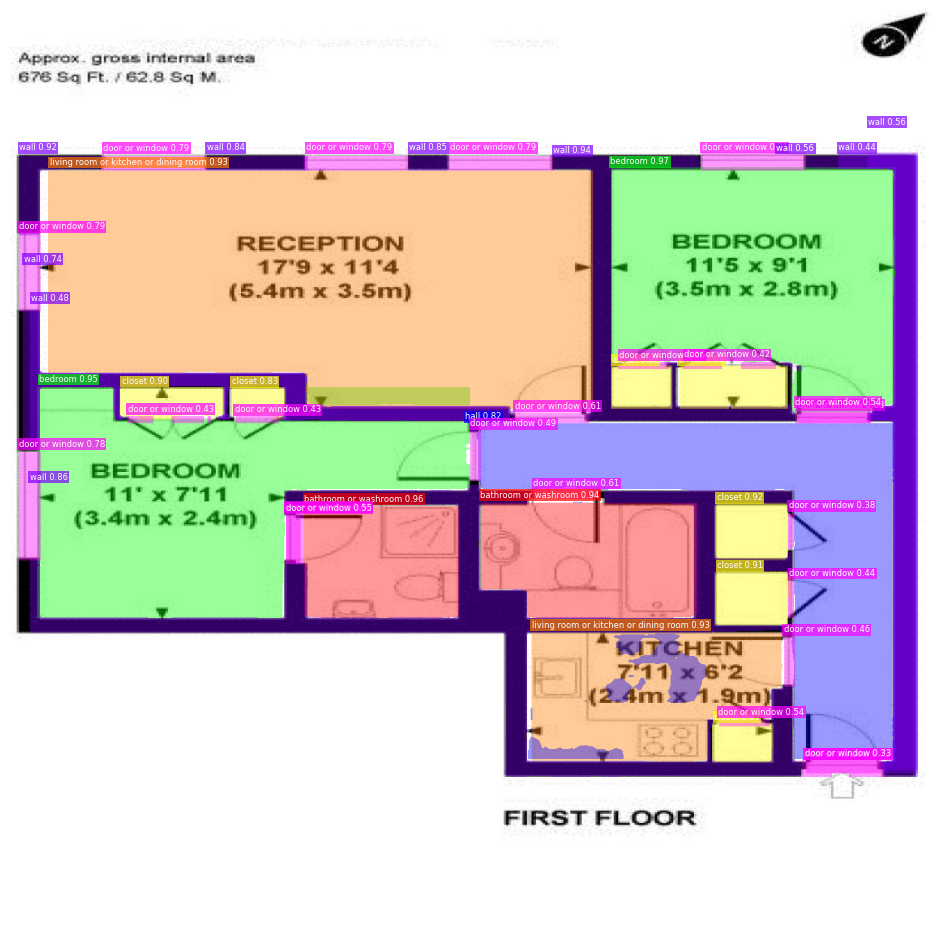

In [24]:
# Load your trained model
model = YOLO("/content/runs/segment/runs/segment/train_smote/weights/best.pt")

# Run inference
img_path = "/content/Rent3D-Floor-Plan-8/valid/images/47490062_jpg.rf.8f470983906d01b7b7cf7e4564d72a3c.jpg"
results = model.predict(source=img_path, imgsz=1024, conf=0.3, save=False, verbose=False)

# Load original image
img = np.array(Image.open(img_path).convert("RGB"))

# Prepare figure
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")

# Get result
r = results[0]
names = model.names  # class names dict {id: name}

if r.masks:
    masks = r.masks.data.cpu().numpy()
    boxes = r.boxes.xyxy.cpu().numpy()
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    scores = r.boxes.conf.cpu().numpy()

    # --- Custom distinct colors per class ---
    custom_colors = [
        (0.0, 1.0, 1.0),  # cyan
        (1.0, 0.0, 0.0),  # red
        (0.0, 1.0, 0.0),  # green
        (1.0, 1.0, 0.0),  # yellow
        (1.0, 0.0, 1.0),  # magenta
        (0.0, 0.0, 1.0),  # blue
        (1.0, 0.5, 0.0),  # orange
        (0.5, 0.0, 1.0),  # purple
    ]
    def get_color(cls_id):
        return custom_colors[cls_id % len(custom_colors)]

    # --- Draw masks with transparency and consistent color per class ---
    for i, mask in enumerate(masks):
        cls_id = cls_ids[i]
        conf = scores[i]
        color = get_color(cls_id)

        # Create RGBA overlay
        colored_mask = np.zeros((*mask.shape, 4))
        colored_mask[..., :3] = color
        colored_mask[..., 3] = mask * 0.4  # transparency
        plt.imshow(colored_mask)

        # Draw label text
        x1, y1, x2, y2 = boxes[i]
        label = f"{names[cls_id]} {conf:.2f}"
        plt.text(
            x1, y1 - 5, label,
            color='white',
            fontsize=6,
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=1)
        )

plt.show()

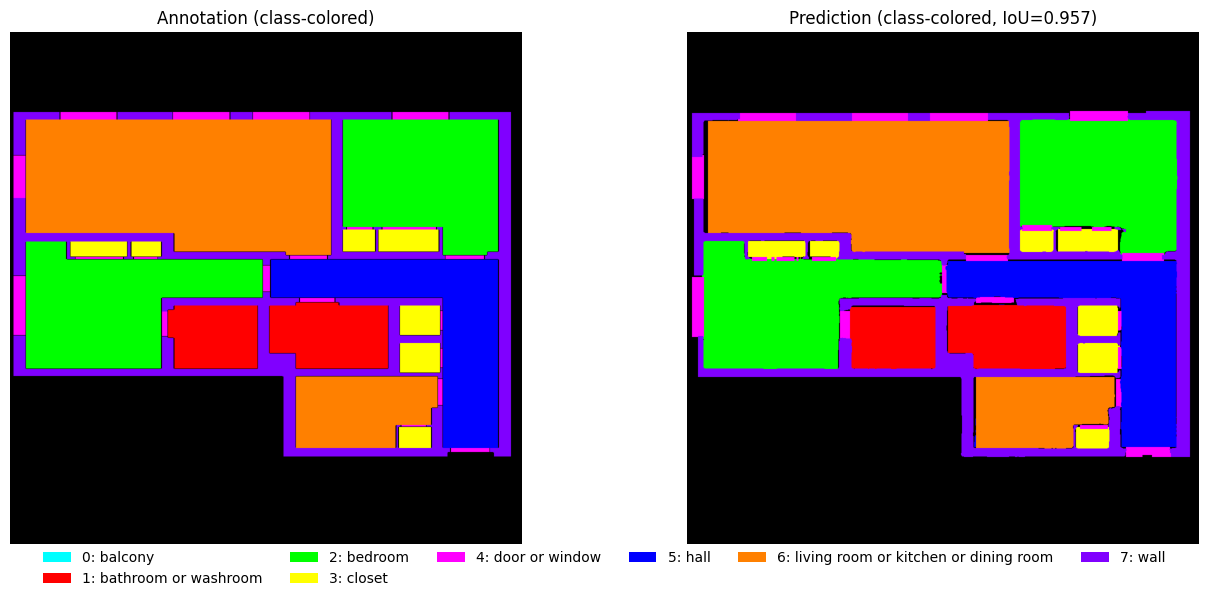

Per-class IoU:
   0      balcony: n/a
   1 bathroom or washroom: 0.932
   2      bedroom: 0.952
   3       closet: 0.874
   4 door or window: 0.594
   5         hall: 0.874
   6 living room or kitchen or dining room: 0.960
   7         wall: 0.835


In [26]:
# ---- paths & model ----
model = YOLO("/content/runs/segment/runs/segment/train_smote/weights/best.pt")
img_path = "/content/Rent3D-Floor-Plan-8/valid/images/47490062_jpg.rf.8f470983906d01b7b7cf7e4564d72a3c.jpg"
label_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

# ---- custom, distinct RGB colors (extend/modify as you like) ----
CUSTOM_COLORS = [
    (0, 255, 255),   # cyan
    (255, 0, 0),     # red
    (0, 255, 0),     # green
    (255, 255, 0),   # yellow
    (255, 0, 255),   # magenta
    (0, 0, 255),     # blue
    (255, 128, 0),   # orange
    (128, 0, 255),   # purple
]
def color_for(cid):  # handles more classes than colors by cycling
    return np.array(CUSTOM_COLORS[cid % len(CUSTOM_COLORS)], dtype=np.uint8)

# ---- inference ----
res = model.predict(source=img_path, imgsz=1024, conf=0.25, save=False, verbose=False)[0]
H, W = res.orig_shape
names = model.names
num_classes = len(names)

# ---- annotation masks from YOLO polygon labels -> per-class binary masks ----
ann_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 2:
                cid = int(parts[0])
                xy = np.array(parts[1:], dtype=float).reshape(-1, 2)
                pts = np.column_stack((xy[:, 0] * W, xy[:, 1] * H)).astype(np.int32)
                cv2.fillPoly(ann_per_class[cid], [pts], 1)

# ---- prediction masks -> per-class binary masks (union over instances) ----
pred_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if res.masks:
    pmasks = (res.masks.data.cpu().numpy() > 0.5)  # (N,H,W)
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    for m, cid in zip(pmasks, cls_ids):
        pred_per_class[cid] |= m.astype(np.uint8)

# ---- colored canvases (annotation & prediction) using custom palette ----
ann_rgb  = np.zeros((H, W, 3), dtype=np.uint8)
pred_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cid in range(num_classes):
    col = color_for(cid)
    ann_rgb[ann_per_class[cid] == 1]  = col
    pred_rgb[pred_per_class[cid] == 1] = col

# ---- compute IoU metrics ----
ann_any  = (ann_per_class.sum(axis=0)  > 0)
pred_any = (pred_per_class.sum(axis=0) > 0)
intersection = ann_any & pred_any
union = ann_any | pred_any
iou_overall = (intersection.sum() / union.sum()) if union.any() else 0.0

# per-class IoU
ious = []
for cid in range(num_classes):
    inter_c = np.logical_and(ann_per_class[cid], pred_per_class[cid]).sum()
    union_c = np.logical_or(ann_per_class[cid], pred_per_class[cid]).sum()
    ious.append(inter_c / union_c if union_c > 0 else np.nan)

# ---- legend for classes ----
legend_patches = []
for cid in range(num_classes):
    col = color_for(cid) / 255.0
    legend_patches.append(Patch(facecolor=col, edgecolor='none', label=f"{cid}: {names.get(cid, str(cid))}"))

# ---- plot (2 columns: annotation and prediction) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(ann_rgb)
ax[0].set_title("Annotation (class-colored)")
ax[0].axis("off")

ax[1].imshow(pred_rgb)
ax[1].set_title(f"Prediction (class-colored, IoU={iou_overall:.3f})")
ax[1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=min(num_classes, 6), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ---- print per-class IoU table ----
print("Per-class IoU:")
for cid, iou_c in enumerate(ious):
    label = names.get(cid, str(cid))
    val = "n/a" if np.isnan(iou_c) else f"{iou_c:.3f}"
    print(f"  {cid:2d} {label:>12s}: {val}")

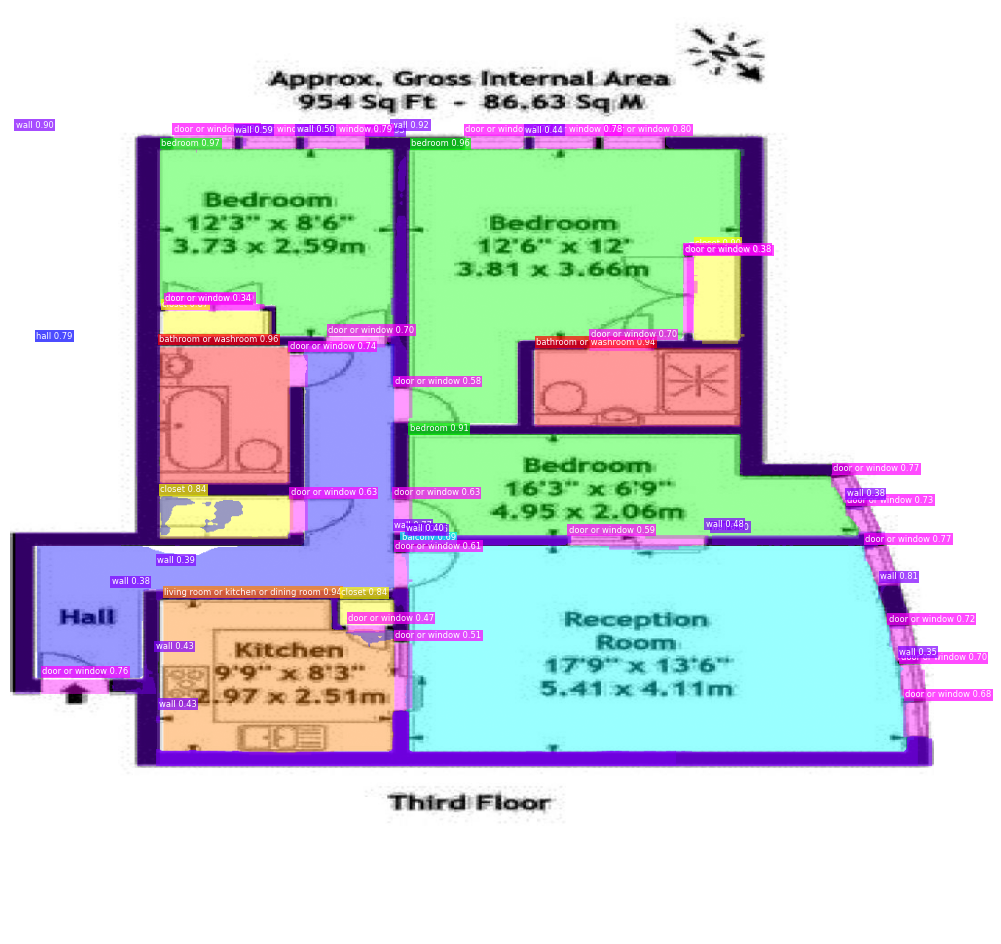

In [27]:
# Load your trained model
model = YOLO("/content/runs/segment/runs/segment/train_smote/weights/best.pt")

# Run inference
img_path = "/content/Rent3D-Floor-Plan-8/valid/images/47545160_jpg.rf.7173af4680619249ae2d00fca094e62c.jpg"
results = model.predict(source=img_path, imgsz=1024, conf=0.3, save=False, verbose=False)

# Load original image
img = np.array(Image.open(img_path).convert("RGB"))

# Prepare figure
plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")

# Get result
r = results[0]
names = model.names  # class names dict {id: name}

if r.masks:
    masks = r.masks.data.cpu().numpy()
    boxes = r.boxes.xyxy.cpu().numpy()
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    scores = r.boxes.conf.cpu().numpy()

    # --- Custom distinct colors per class ---
    custom_colors = [
        (0.0, 1.0, 1.0),  # cyan
        (1.0, 0.0, 0.0),  # red
        (0.0, 1.0, 0.0),  # green
        (1.0, 1.0, 0.0),  # yellow
        (1.0, 0.0, 1.0),  # magenta
        (0.0, 0.0, 1.0),  # blue
        (1.0, 0.5, 0.0),  # orange
        (0.5, 0.0, 1.0),  # purple
    ]
    def get_color(cls_id):
        return custom_colors[cls_id % len(custom_colors)]

    # --- Draw masks with transparency and consistent color per class ---
    for i, mask in enumerate(masks):
        cls_id = cls_ids[i]
        conf = scores[i]
        color = get_color(cls_id)

        # Create RGBA overlay
        colored_mask = np.zeros((*mask.shape, 4))
        colored_mask[..., :3] = color
        colored_mask[..., 3] = mask * 0.4  # transparency
        plt.imshow(colored_mask)

        # Draw label text
        x1, y1, x2, y2 = boxes[i]
        label = f"{names[cls_id]} {conf:.2f}"
        plt.text(
            x1, y1 - 5, label,
            color='white',
            fontsize=6,
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=1)
        )

plt.show()

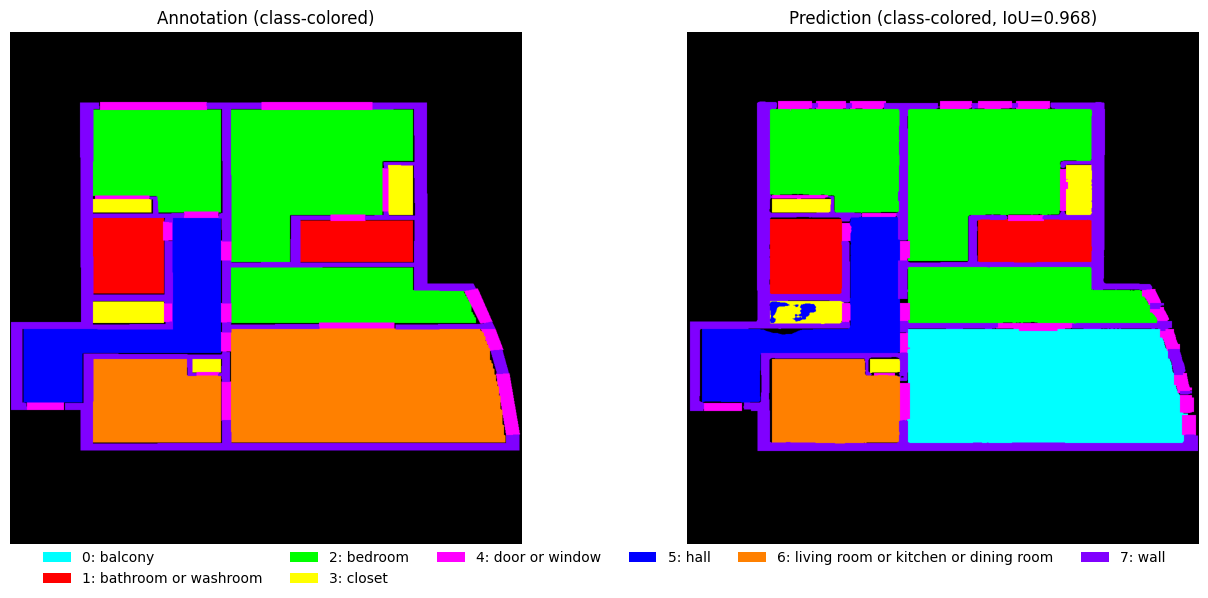

Per-class IoU:
   0      balcony: 0.000
   1 bathroom or washroom: 0.939
   2      bedroom: 0.970
   3       closet: 0.876
   4 door or window: 0.734
   5         hall: 0.904
   6 living room or kitchen or dining room: 0.245
   7         wall: 0.861


In [28]:
# ---- paths & model ----
model = YOLO("/content/runs/segment/runs/segment/train_smote/weights/best.pt")
img_path = "/content/Rent3D-Floor-Plan-8/valid/images/47545160_jpg.rf.7173af4680619249ae2d00fca094e62c.jpg"
label_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"

# ---- custom, distinct RGB colors (extend/modify as you like) ----
CUSTOM_COLORS = [
    (0, 255, 255),   # cyan
    (255, 0, 0),     # red
    (0, 255, 0),     # green
    (255, 255, 0),   # yellow
    (255, 0, 255),   # magenta
    (0, 0, 255),     # blue
    (255, 128, 0),   # orange
    (128, 0, 255),   # purple
]
def color_for(cid):  # handles more classes than colors by cycling
    return np.array(CUSTOM_COLORS[cid % len(CUSTOM_COLORS)], dtype=np.uint8)

# ---- inference ----
res = model.predict(source=img_path, imgsz=1024, conf=0.25, save=False, verbose=False)[0]
H, W = res.orig_shape
names = model.names
num_classes = len(names)

# ---- annotation masks from YOLO polygon labels -> per-class binary masks ----
ann_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 2:
                cid = int(parts[0])
                xy = np.array(parts[1:], dtype=float).reshape(-1, 2)
                pts = np.column_stack((xy[:, 0] * W, xy[:, 1] * H)).astype(np.int32)
                cv2.fillPoly(ann_per_class[cid], [pts], 1)

# ---- prediction masks -> per-class binary masks (union over instances) ----
pred_per_class = np.zeros((num_classes, H, W), dtype=np.uint8)
if res.masks:
    pmasks = (res.masks.data.cpu().numpy() > 0.5)  # (N,H,W)
    cls_ids = res.boxes.cls.cpu().numpy().astype(int)
    for m, cid in zip(pmasks, cls_ids):
        pred_per_class[cid] |= m.astype(np.uint8)

# ---- colored canvases (annotation & prediction) using custom palette ----
ann_rgb  = np.zeros((H, W, 3), dtype=np.uint8)
pred_rgb = np.zeros((H, W, 3), dtype=np.uint8)
for cid in range(num_classes):
    col = color_for(cid)
    ann_rgb[ann_per_class[cid] == 1]  = col
    pred_rgb[pred_per_class[cid] == 1] = col

# ---- compute IoU metrics ----
ann_any  = (ann_per_class.sum(axis=0)  > 0)
pred_any = (pred_per_class.sum(axis=0) > 0)
intersection = ann_any & pred_any
union = ann_any | pred_any
iou_overall = (intersection.sum() / union.sum()) if union.any() else 0.0

# per-class IoU
ious = []
for cid in range(num_classes):
    inter_c = np.logical_and(ann_per_class[cid], pred_per_class[cid]).sum()
    union_c = np.logical_or(ann_per_class[cid], pred_per_class[cid]).sum()
    ious.append(inter_c / union_c if union_c > 0 else np.nan)

# ---- legend for classes ----
legend_patches = []
for cid in range(num_classes):
    col = color_for(cid) / 255.0
    legend_patches.append(Patch(facecolor=col, edgecolor='none', label=f"{cid}: {names.get(cid, str(cid))}"))

# ---- plot (2 columns: annotation and prediction) ----
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(ann_rgb)
ax[0].set_title("Annotation (class-colored)")
ax[0].axis("off")

ax[1].imshow(pred_rgb)
ax[1].set_title(f"Prediction (class-colored, IoU={iou_overall:.3f})")
ax[1].axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=min(num_classes, 6), frameon=False)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ---- print per-class IoU table ----
print("Per-class IoU:")
for cid, iou_c in enumerate(ious):
    label = names.get(cid, str(cid))
    val = "n/a" if np.isnan(iou_c) else f"{iou_c:.3f}"
    print(f"  {cid:2d} {label:>12s}: {val}")

### **6. Save the model folder**

In [25]:
import shutil
from google.colab import files

# Path to runs folder
runs_dir = "/content/runs/segment/runs/segment/train_smote"
zip_path = "/content/runs.zip"

# Zip the folder
shutil.make_archive(base_name="/content/runs", format="zip", root_dir=runs_dir)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>